In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import func

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = func.downsize_mnist(x_train)
mean_train = x_train.mean(axis=0)
x_train = x_train - mean_train

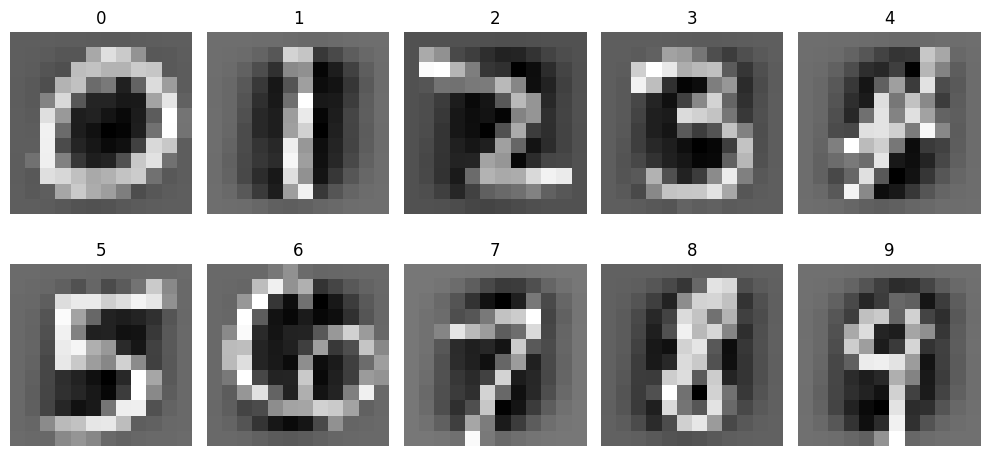

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for digit in range(10):
    idx = np.random.choice(np.where(y_train == digit)[0])
    axes[digit//5, digit%5].imshow(x_train[idx], cmap='gray')
    axes[digit//5, digit%5].set_title(digit)
    axes[digit//5, digit%5].axis('off')
plt.tight_layout()
# plt.savefig('sampled_digits.pdf')


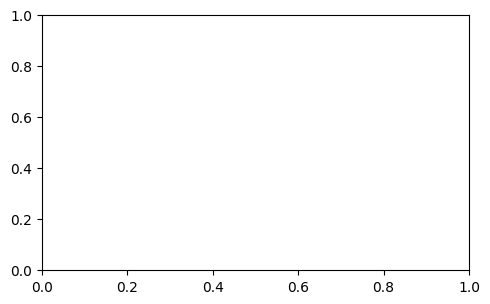

In [23]:
fig = plt.figure(figsize=(5, 5), tight_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[3, 2])

ax_top = fig.add_subplot(gs[0])

sub_gs = gs[1].subgridspec(2, 5)
axes = np.empty((2, 5), dtype=object)

plt.show()



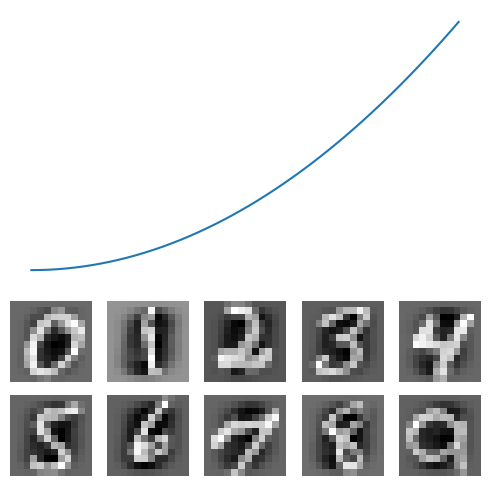

In [16]:

fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 2])

# Top figure
xs = np.linspace(0, 1)
ax_top = fig.add_subplot(gs[0])
ax_top.plot(xs, xs**2) 
ax_top.axis('off')

# Bottom digit grid
sub_gs = gs[1].subgridspec(2, 5)
axes = np.empty((2, 5), dtype=object)
for digit in range(10):
    axes[digit//5, digit%5] = fig.add_subplot(sub_gs[digit//5, digit%5])
    idx = np.random.choice(np.where(y_train == digit)[0])
    axes[digit//5, digit%5].imshow(x_train[idx], cmap='gray')
    axes[digit//5, digit%5].axis('off')

plt.tight_layout()
plt.show()


## Images generated

In [22]:
_, d, _ = x_train.shape
x_train = x_train.reshape(len(x_train), -1)
cov_train = np.cov(x_train, rowvar=False)
sqrt_C = func.sqrt_mat(cov_train)


In [25]:
def generate_image():
    z = np.random.randn(d**2)
    x_gen = sqrt_C@z
    x_gen = x_gen.reshape(d,d)
    return x_gen + mean_train
    # return x_gen

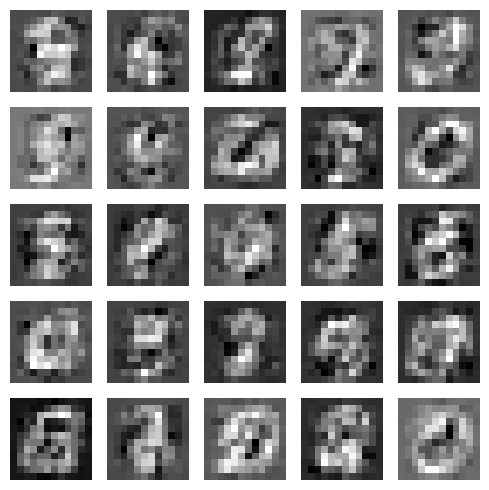

In [26]:
M = 5
fig, axes = plt.subplots(M, M, figsize=(M, M))
for i in range(M**2):
    axes[i//M, i%M].imshow(generate_image(), cmap='gray')
    axes[i//M, i%M].axis('off')
plt.tight_layout()